In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
psr_1 = pd.read_csv('../../raw_datasets/psr_raw/Kds_Omi32g.tsv',sep='\t')
psr_2 = pd.read_csv('../../raw_datasets/psr_raw/Kds_Omi32h.tsv',sep='\t')

psr_1['geno']=psr_1['geno'].astype('string').str.zfill(13)
psr_2['geno']=psr_2['geno'].astype('string').str.zfill(13)

psr_3 = pd.merge(psr_1,psr_2,on='geno',suffixes=('_r1','_r2'))
psr_3_clean = psr_3.loc[(psr_3['r2_r1']>0.8)&(psr_3['r2_r2']>0.8)&(psr_3['sigma_r1']<1)&(psr_3['sigma_r2']<1)].copy()
psr_3_clean.to_csv('psr_cleaned.csv',index=False)


psr_nohill_pre-processing:
  Canvas size: 1 × 1 inches
  Total figure size: 1.80 × 1.70 inches
  At 2000 DPI: 3600 × 3400 pixels
  N = 8184 (99.9%)
  Pearson r = 0.105
  Spearman ρ = 0.124


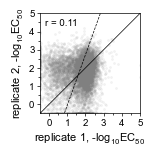


psr_nohill_post-processing:
  Canvas size: 1 × 1 inches
  Total figure size: 1.80 × 1.70 inches
  At 2000 DPI: 3600 × 3400 pixels
  N = 5510 (67.3%)
  Pearson r = 0.162
  Spearman ρ = 0.177


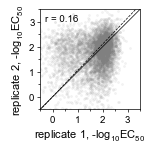

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from scipy import odr 
from matplotlib.gridspec import GridSpec

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

psr_1 = pd.read_csv('psr_raw/Kds_Omi32g.tsv', sep='\t')
psr_2 = pd.read_csv('psr_raw/Kds_Omi32h.tsv', sep='\t')
psr_all = pd.read_csv('psr_cleaned.csv')

psr_1['geno'] = psr_1['geno'].astype('string').str.zfill(13)
psr_2['geno'] = psr_2['geno'].astype('string').str.zfill(13)
psr_all['geno'] = psr_all['geno'].astype('string').str.zfill(13)

psr_3 = pd.merge(psr_1, psr_2, on='geno', suffixes=('_r1', '_r2'))
psr_3_merge = psr_3.loc[
    (psr_3['r2_r1'] > 0.8) &
    (psr_3['r2_r2'] > 0.8) &
    (psr_3['sigma_r1'] < 1) &
    (psr_3['sigma_r2'] < 1)
].copy()

def make_corr_plot(df, title, filename, xlim_max, ylim_max):
    x = df['PSR_log10EC50_r1']
    y = df['PSR_log10EC50_r2']

    mask = ~(x.isna() | y.isna())
    x = x[mask]
    y = y[mask]

    N = len(x)
    pct = N / 8192 * 100

    r_pearson, p_p = pearsonr(x, y)
    r_spear, p_s = spearmanr(x, y)

    CANVAS_WIDTH = 1
    CANVAS_HEIGHT = 1

    LEFT_MARGIN = 0.6
    RIGHT_MARGIN = 0.2
    TOP_MARGIN = 0.2
    BOTTOM_MARGIN = 0.5

    fig_width = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
    fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN

    fig = plt.figure(figsize=(fig_width, fig_height))

    gs = GridSpec(1, 1, figure=fig,
                  left=LEFT_MARGIN/fig_width,
                  right=(LEFT_MARGIN + CANVAS_WIDTH)/fig_width,
                  top=1 - TOP_MARGIN/fig_height,
                  bottom=BOTTOM_MARGIN/fig_height)

    ax = fig.add_subplot(gs[0])

    sns.scatterplot(x=x, y=y, s=3, color='gray', ax=ax,alpha=0.1, edgecolor=None)

    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lims, lims, 'k-', lw=0.5)

    # correlation line orthogonal least-squares regression via scipy.odr
    x0 = np.asarray(x, float)
    y0 = np.asarray(y, float)
    m = np.isfinite(x0) & np.isfinite(y0)
    x0, y0 = x0[m], y0[m]

    def _f(B, x):
        return B[0] * x + B[1] 

    model = odr.Model(_f)
    data = odr.RealData(x0, y0)  # equal weights -> TLS-like orthogonal regression
    odr_obj = odr.ODR(data, model, beta0=[1.0, 0.0])
    out = odr_obj.run()
    slope, intercept = out.beta


    xlims = ax.get_xlim()
    x_line = np.array(xlims)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'k--', lw=0.5)


    ax.set_xlim(-0.5, xlim_max)
    ax.set_ylim(-0.5, ylim_max)
    
    if xlim_max == 5:
        ax.set_xticks([0, 1, 2, 3, 4, 5])
        ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], minor=True)
    else: 
        ax.set_xticks([0, 1, 2, 3])
        ax.set_xticks([-0.5, 0.5, 1.5, 2.5, 3.0, 3.5], minor=True)
    
    if ylim_max == 5:
        ax.set_yticks([0, 1, 2, 3, 4, 5])
        ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], minor=True)
    else:  
        ax.set_yticks([0, 1, 2, 3])
        ax.set_yticks([-0.5, 0.5, 1.5, 2.5, 3.5], minor=True)

    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel('replicate 1, -log$_{10}$EC$_{50}$', fontsize=8, labelpad=2)
    ax.set_ylabel('replicate 2, -log$_{10}$EC$_{50}$', fontsize=8, labelpad=2)

    ax.tick_params(axis='both', which='major', labelsize=7, pad=2, length=2, width=0.5, direction='out')
    ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, direction='out')

    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    ax.text(0.05, 0.95, f'r = {r_pearson:.2f}',
            transform=ax.transAxes,
            fontsize=7,
            va='top',
            ha='left')

    plt.savefig(f"{filename}.png", dpi=2000, bbox_inches='tight', transparent=True)
    plt.savefig(f"{filename}.pdf", bbox_inches='tight', transparent=True)
    
    print(f'\n{title}:')
    print(f'  Canvas size: {CANVAS_WIDTH} × {CANVAS_HEIGHT} inches')
    print(f'  Total figure size: {fig_width:.2f} × {fig_height:.2f} inches')
    print(f'  At 2000 DPI: {int(fig_width * 2000)} × {int(fig_height * 2000)} pixels')
    print(f'  N = {N} ({pct:.1f}%)')
    print(f'  Pearson r = {r_pearson:.3f}')
    print(f'  Spearman ρ = {r_spear:.3f}')
    
    plt.show()

make_corr_plot(psr_3, "psr_nohill_pre-processing", "psr_nohill_pre-processing", xlim_max=5, ylim_max=5)
make_corr_plot(psr_3_merge, "psr_nohill_post-processing", "psr_nohill_post-processing", xlim_max=3.5, ylim_max=3.5)